# Import

In [480]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
import numpy as np
from sklearn.preprocessing import OrdinalEncoder , StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')


## Config

In [481]:
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Enabled memory growth for {gpu}")
    except Exception as e:
        print(e)

# Functions

In [482]:
global_split_index_1 = 0
global_split_index_2 = 0

In [483]:
def make_ds(series, seq_length, batch_size, target, shuffle=False):
    x = series.drop(columns=target).to_numpy()
    y = series[target].to_numpy().astype("float32")    # always slice from the numpy array
    y = y[seq_length:]

    return tf.keras.utils.timeseries_dataset_from_array(
        data=x,
        targets=y,
        sequence_length=seq_length,
        batch_size=batch_size,
        shuffle=shuffle,
        seed=42
    )

def train_valid_test_split(df, train_pct=0.90, valid_pct=0.10):

    split_index_1 = int(len(df) * train_pct)
    split_index_2 = int(len(df) * (train_pct+valid_pct))

    global global_split_index_1
    global global_split_index_2

    global_split_index_1 = split_index_1
    global_split_index_2 = split_index_2

    train_df = df.iloc[:split_index_1].copy()
    valid_df = df.iloc[split_index_1:split_index_2].copy()
    # test_df = df.iloc[split_index_2:].copy()


    print(f"""
        split index 1: {split_index_1}
        split index 2: {split_index_2}""")
    return (train_df, valid_df)

def reuse_split(df):

    global global_split_index_1
    global global_split_index_2

    train_df = df.iloc[:global_split_index_1].copy()
    valid_df = df.iloc[global_split_index_1:global_split_index_2].copy()
    # test_df = df.iloc[global_split_index_2:].copy()

    return (train_df, valid_df)

# Load Data

## Tracks

In [484]:
Bahrain_df_fp1_2022 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2022_FP1.csv")
Bahrain_df_fp1_2022["Session"] = 1
Bahrain_df_fp1_2022["year"] = 2022
Bahrain_df_fp2_2022 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2022_FP2.csv")
Bahrain_df_fp2_2022["Session"] = 2
Bahrain_df_fp2_2022["year"] = 2022
Bahrain_df_fp3_2022 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2022_FP3.csv")
Bahrain_df_fp3_2022["Session"] = 3
Bahrain_df_fp3_2022["year"] = 2022
Bahrain_df_race_2022 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2022_R.csv")
Bahrain_df_race_2022["Session"] = 4
Bahrain_df_race_2022["year"] = 2022

Bahrain_df_fp1_2023 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2023_FP1.csv")
Bahrain_df_fp1_2023["Session"] = 1
Bahrain_df_fp1_2023["year"] = 2023
Bahrain_df_fp2_2023 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2023_FP2.csv")
Bahrain_df_fp2_2023["Session"] = 2
Bahrain_df_fp2_2023["year"] = 2023
Bahrain_df_fp3_2023 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2023_FP3.csv")
Bahrain_df_fp3_2023["Session"] = 3
Bahrain_df_fp3_2023["year"] = 2023
Bahrain_df_race_2023 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2023_R.csv")
Bahrain_df_race_2023["Session"] = 4
Bahrain_df_race_2023["year"] = 2023

Bahrain_df_fp1_2024 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2024_FP1.csv")
Bahrain_df_fp1_2024["Session"] = 1
Bahrain_df_fp1_2024["year"] = 2024
Bahrain_df_fp2_2024 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2024_FP2.csv")
Bahrain_df_fp2_2024["Session"] = 2
Bahrain_df_fp2_2024["year"] = 2024
Bahrain_df_fp3_2024 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2024_FP3.csv")
Bahrain_df_fp3_2024["Session"] = 3
Bahrain_df_fp3_2024["year"] = 2024
Bahrain_df_race_2024 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2024_R.csv")
Bahrain_df_race_2024["Session"] = 4
Bahrain_df_race_2024["year"] = 2024

Bahrain_df_fp1_2025 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2025_FP1.csv")
Bahrain_df_fp1_2025["Session"] = 1
Bahrain_df_fp1_2025["year"] = 2025
Bahrain_df_fp2_2025 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2025_FP2.csv")
Bahrain_df_fp2_2025["Session"] = 2
Bahrain_df_fp2_2025["year"] = 2025
Bahrain_df_fp3_2025 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2025_FP3.csv")
Bahrain_df_fp3_2025["Session"] = 3
Bahrain_df_fp3_2025["year"] = 2025
Bahrain_df_race_2025 = pd.read_csv("Bahrains/Round_1_Bahrain Grand Prix_2025_R.csv")
Bahrain_df_race_2025["Session"] = 4
Bahrain_df_race_2025["year"] = 2025

Bahrain_df = pd.concat([Bahrain_df_fp1_2022,
                        Bahrain_df_fp2_2022,
                        Bahrain_df_fp3_2022,
                        Bahrain_df_race_2022,
                        Bahrain_df_fp1_2023,
                        Bahrain_df_fp2_2023,
                        Bahrain_df_fp3_2023,
                        Bahrain_df_race_2023,
                        Bahrain_df_fp1_2024,
                        Bahrain_df_fp2_2024,
                        Bahrain_df_fp3_2024,
                        Bahrain_df_race_2024,
                        Bahrain_df_fp1_2025,
                        Bahrain_df_fp2_2025,
                        Bahrain_df_fp3_2025,
                        Bahrain_df_race_2025,
                        ])


## concat all

In [485]:
# total_df = pd.concat([Bahrain_df,Bahrainn_df])

# total_df = pd.concat([Bahrain_df,Bahrainn_df,Australian_df,Emilia_Romagna_df,Spanish_df,Azerbaijan_df,Canadian_df,British_df,Austrian_df,French_df,Hungarian_df,Belgian_df,Dutch_df,Italian_df,Singapore_df,Japanese_df,United_States_df,Mexico_City_df,Sao_Paulo_df,Abu_Dhabi_df])

# Filters

In [486]:
Bahrain_df.columns

Index(['Unnamed: 0', 'Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber',
       'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time',
       'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime',
       'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST',
       'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team',
       'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted',
       'DeletedReason', 'FastF1Generated', 'IsAccurate', 'AirTemp', 'Humidity',
       'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed',
       'Circuit', 'Track_length', 'Number_of_corners', 'Session', 'year'],
      dtype='object')

In [487]:
# Bahrainn_df = Bahrainn_df[Bahrainn_df["TrackStatus"] == 1]       ## focusing purely on green flag laps causes continuity issues

In [488]:
Bahrain_df.to_csv("bahrains.csv")

Bahrain_df = Bahrain_df.dropna(subset=["Sector1Time", "Sector2Time","Sector3Time"])

# column management

In [489]:
Bahrain_Ver_df = Bahrain_df.copy()

In [490]:
Bahrain_Ver_df["SC_active"] = (
    Bahrain_Ver_df["TrackStatus"]
    .astype("string")                      # robust to mixed types/NaN
    .str.contains("4")
    .astype("int32")
)


In [491]:
Bahrain_Ver_df = Bahrain_Ver_df[Bahrain_Ver_df["Driver"] == "VER"]
Bahrain_Ver_df = Bahrain_Ver_df.drop(columns=["Unnamed: 0","DriverNumber","Driver","Time","IsPersonalBest","LapStartTime","Position","Deleted","DeletedReason", "FastF1Generated", "IsAccurate",'Sector1SessionTime',
       'Sector2SessionTime', 'Sector3SessionTime','FreshTyre',"SpeedI1","SpeedI2","SpeedFL","SpeedST","Team","LapTime","PitOutTime","PitInTime","Rainfall","Pressure","Humidity","TrackStatus",])

no more sector time melt, keep them as columns and now they are 3 targets for 3 models. or maybe 3 targets for one?

In [492]:
Bahrain_Ver_df = Bahrain_Ver_df.sort_values(            # sorting by lap start date/time
    by=["LapStartDate"],
    ascending=True
)

Bahrain_Ver_df = Bahrain_Ver_df.drop(columns="LapStartDate")

In [493]:

rad = np.deg2rad(Bahrain_Ver_df["WindDirection"])
Bahrain_Ver_df["WindDir_sin"] = np.sin(rad)
Bahrain_Ver_df["WindDir_cos"] = np.cos(rad)
Bahrain_Ver_df.drop(columns=["WindDirection"], inplace=True)


In [494]:
Bahrain_Ver_df = Bahrain_Ver_df.reset_index(drop=True)

window_size = 10


for i in range (1,4):
    Bahrain_Ver_df[f"Sector{i}Time"] = pd.to_timedelta(Bahrain_Ver_df[f"Sector{i}Time"])
    Bahrain_Ver_df[f"Sector{i}Time"] = Bahrain_Ver_df[f"Sector{i}Time"].dt.total_seconds()

    # Bahrain_Ver_df = Bahrain_Ver_df.dropna(subset=[f"Sector{i}Time"])                                                 #lazy destructive method
    roll_medians = Bahrain_Ver_df[f"Sector{i}Time"].rolling(window=window_size, min_periods=1).median()
    Bahrain_Ver_df[f"Sector{i}Time"] = Bahrain_Ver_df[f"Sector{i}Time"].fillna(roll_medians)


implementing 107% rule in the form of clipping to deal with extreme times in training data (safety cars for example) again not the best solution but simple enough for testing

In [495]:
# for col in ["Sector1Time", "Sector2Time", "Sector3Time"]:

#     baseline = Bahrain_Ver_df[col].rolling(window=window_size, min_periods=1).mean()
#     clip_level = 1.07 * baseline
#     Bahrain_Ver_df[col] = Bahrain_Ver_df[col].clip(upper=clip_level)


Bahrain_Ver_df["TyreLife"] = Bahrain_Ver_df["TyreLife"].ffill()

# Splitting

In [496]:
Train_test_valid_sector1_df = Bahrain_Ver_df.copy()
Train_test_valid_sector2_df = Bahrain_Ver_df.copy()
Train_test_valid_sector3_df = Bahrain_Ver_df.copy()

Train_test_valid_sector1_df = Train_test_valid_sector1_df.drop(columns=["Sector2Time","Sector3Time"])
Train_test_valid_sector2_df = Train_test_valid_sector2_df.drop(columns=["Sector1Time","Sector3Time"])
Train_test_valid_sector3_df = Train_test_valid_sector3_df.drop(columns=["Sector1Time","Sector2Time"])

Train_valid_sector1_df = Train_test_valid_sector1_df[~((Train_test_valid_sector1_df["Session"] == 4) & (Train_test_valid_sector1_df["year"] == 2025))]
Train_valid_sector2_df = Train_test_valid_sector2_df[~((Train_test_valid_sector2_df["Session"] == 4) & (Train_test_valid_sector2_df["year"] == 2025))]
Train_valid_sector3_df = Train_test_valid_sector3_df[~((Train_test_valid_sector3_df["Session"] == 4) & (Train_test_valid_sector3_df["year"] == 2025))]

old version of sliptting below now we are using one race session as test  and all previous sessions including previous races as train

In [497]:
Ver_train_sector1, Ver_valid_sector1 = train_valid_test_split(Train_valid_sector1_df)
Ver_train_sector2, Ver_valid_sector2 = reuse_split(Train_valid_sector2_df,)
Ver_train_sector3, Ver_valid_sector3 = reuse_split(Train_valid_sector3_df)

Ver_test_sector1 = Train_test_valid_sector1_df[(Train_test_valid_sector1_df["Session"] == 4) & (Train_test_valid_sector1_df["year"] == 2025)]
Ver_test_sector2 = Train_test_valid_sector2_df[(Train_test_valid_sector2_df["Session"] == 4) & (Train_test_valid_sector2_df["year"] == 2025)]
Ver_test_sector3 = Train_test_valid_sector3_df[(Train_test_valid_sector3_df["Session"] == 4) & (Train_test_valid_sector3_df["year"] == 2025)]


        split index 1: 270
        split index 2: 300


# Encoding and numerical formatting

In [498]:
ints_that_should_not_be_floats = ['LapNumber','Stint','TyreLife',"Number_of_corners"]
categorical_cols = ["Compound","Circuit"]

ordinal_encoder_1 = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,            # all unseen categories map to -1
    encoded_missing_value=-2     # missing values map to -2
)
ordinal_encoder_2 = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,            
    encoded_missing_value=-2     
)
ordinal_encoder_3 = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,            
    encoded_missing_value=-2    
)

## S1

ordinal_encoder_1.fit(Ver_train_sector1[categorical_cols])

Ver_train_sector1[categorical_cols] = ordinal_encoder_1.transform(Ver_train_sector1[categorical_cols]).astype("int32")
Ver_train_sector1[ints_that_should_not_be_floats] = Ver_train_sector1[ints_that_should_not_be_floats].astype("int32")

Ver_valid_sector1[categorical_cols] = ordinal_encoder_1.transform(Ver_valid_sector1[categorical_cols]).astype("int32")
Ver_valid_sector1[ints_that_should_not_be_floats] = Ver_valid_sector1[ints_that_should_not_be_floats].astype("int32")

Ver_test_sector1[categorical_cols] = ordinal_encoder_1.transform(Ver_test_sector1[categorical_cols]).astype("int32")
Ver_test_sector1[ints_that_should_not_be_floats] = Ver_test_sector1[ints_that_should_not_be_floats].astype("int32")

## S2

ordinal_encoder_2.fit(Ver_train_sector2[categorical_cols])

Ver_train_sector2[categorical_cols] = ordinal_encoder_2.transform(Ver_train_sector2[categorical_cols]).astype("int32")
Ver_train_sector2[ints_that_should_not_be_floats] = Ver_train_sector2[ints_that_should_not_be_floats].astype("int32")

Ver_valid_sector2[categorical_cols] = ordinal_encoder_2.transform(Ver_valid_sector2[categorical_cols]).astype("int32")
Ver_valid_sector2[ints_that_should_not_be_floats] = Ver_valid_sector2[ints_that_should_not_be_floats].astype("int32")

Ver_test_sector2[categorical_cols] = ordinal_encoder_2.transform(Ver_test_sector2[categorical_cols]).astype("int32")
Ver_test_sector2[ints_that_should_not_be_floats] = Ver_test_sector2[ints_that_should_not_be_floats].astype("int32")

## S3

ordinal_encoder_3.fit(Ver_train_sector3[categorical_cols])

Ver_train_sector3[categorical_cols] = ordinal_encoder_3.transform(Ver_train_sector3[categorical_cols]).astype("int32")
Ver_train_sector3[ints_that_should_not_be_floats] = Ver_train_sector3[ints_that_should_not_be_floats].astype("int32")

Ver_valid_sector3[categorical_cols] = ordinal_encoder_3.transform(Ver_valid_sector3[categorical_cols]).astype("int32")
Ver_valid_sector3[ints_that_should_not_be_floats] = Ver_valid_sector3[ints_that_should_not_be_floats].astype("int32")

Ver_test_sector3[categorical_cols] = ordinal_encoder_3.transform(Ver_test_sector3[categorical_cols]).astype("int32")
Ver_test_sector3[ints_that_should_not_be_floats] = Ver_test_sector3[ints_that_should_not_be_floats].astype("int32")


/tmp/ipykernel_213099/1776632001.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Ver_test_sector1[categorical_cols] = ordinal_encoder_1.transform(Ver_test_sector1[categorical_cols]).astype("int32")
/tmp/ipykernel_213099/1776632001.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Ver_test_sector1[ints_that_should_not_be_floats] = Ver_test_sector1[ints_that_should_not_be_floats].astype("int32")
/tmp/ipykernel_213099/1776632001.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

In [499]:
sect_1_corr_matrix = Ver_train_sector1.corr()
sect_2_corr_matrix = Ver_train_sector2.corr()
sect_3_corr_matrix = Ver_train_sector3.corr()



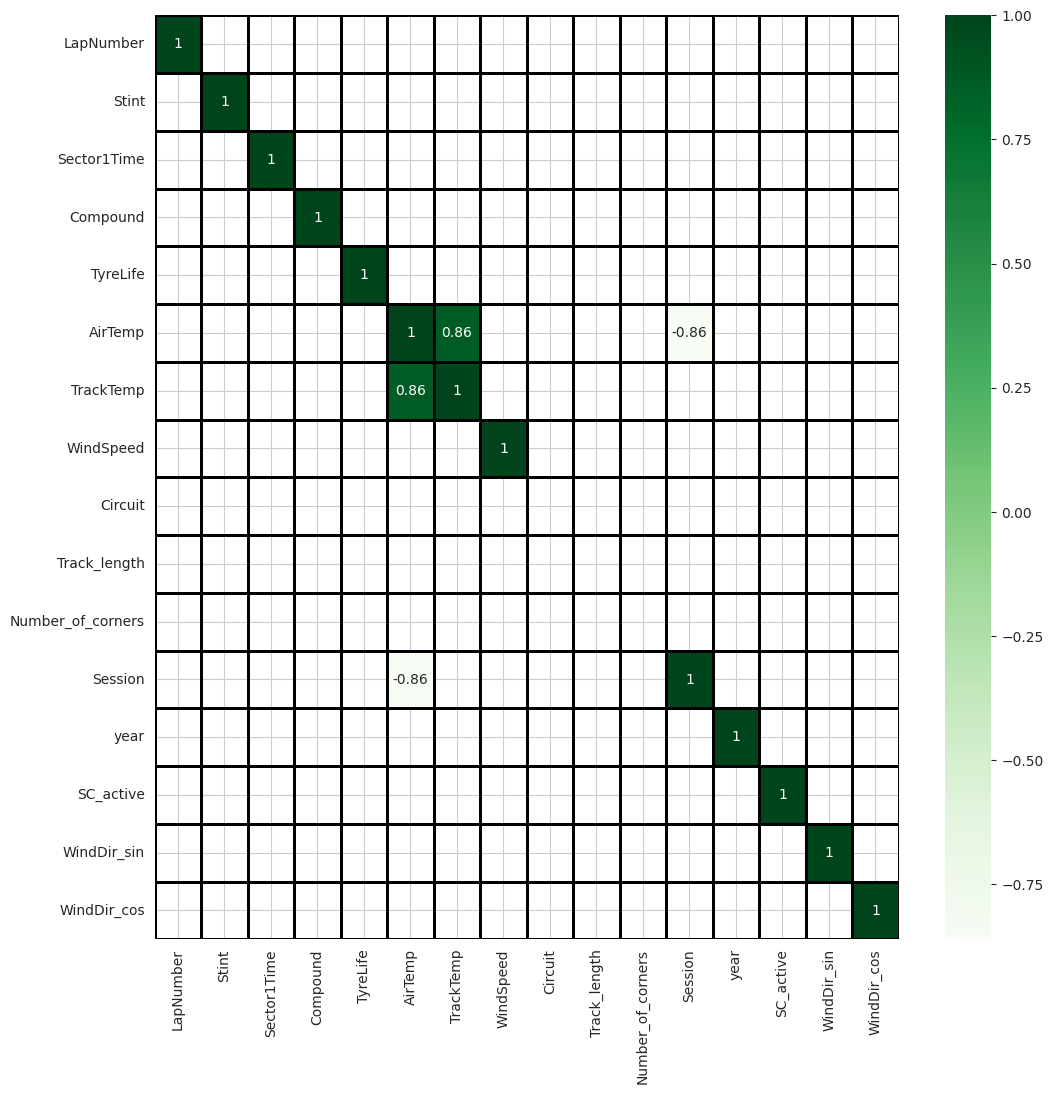

In [500]:
plt.figure(figsize=(12,12))
sns.heatmap(
    sect_1_corr_matrix,
    mask = sect_1_corr_matrix.abs() < 0.8,     ## our threshold for colienarity suspicion is 80% correlation between features
    annot=True,
    cmap="Greens",
    linewidths=0.75,
    linecolor="black"
    )
plt.show()

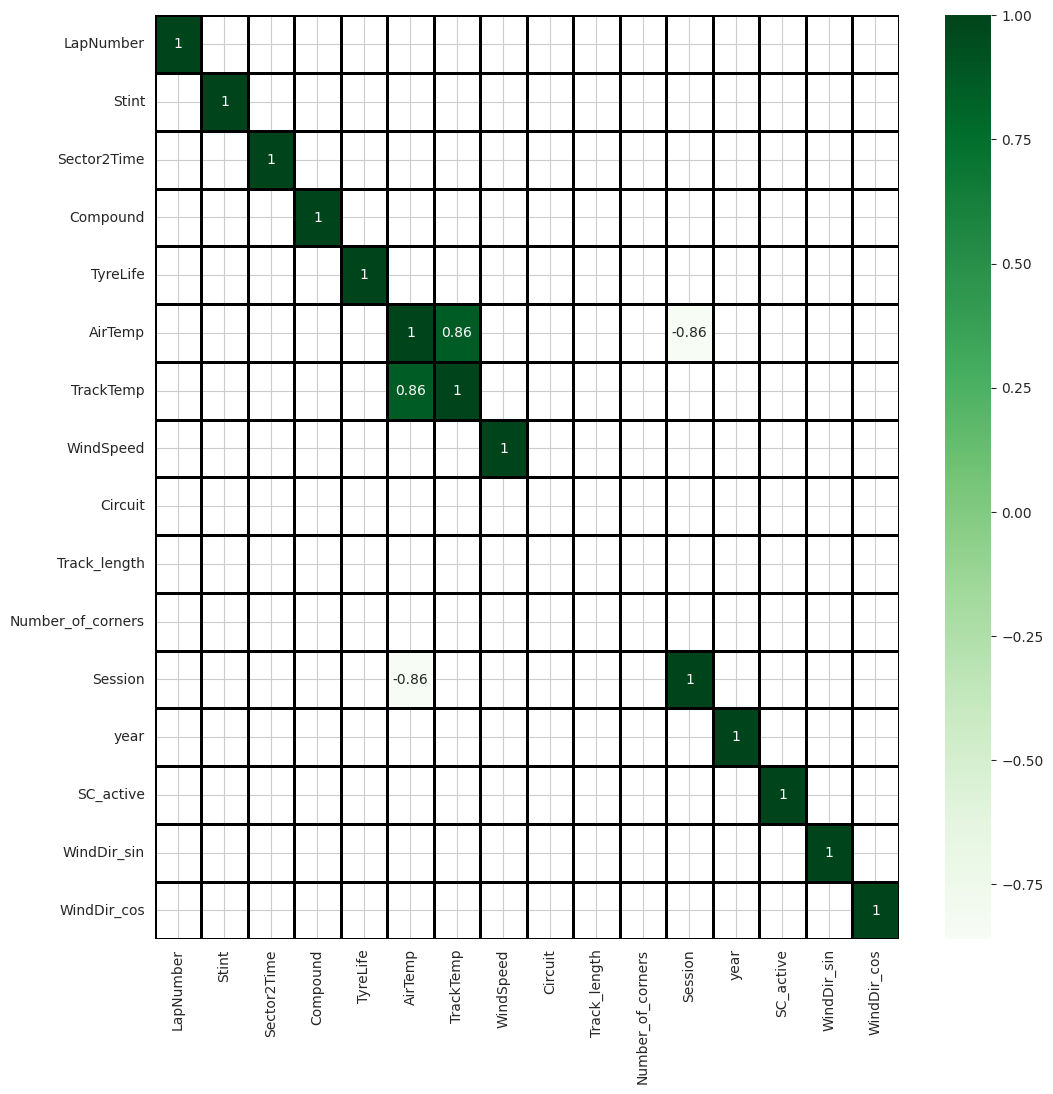

In [501]:
plt.figure(figsize=(12,12))
sns.heatmap(
    sect_2_corr_matrix,
    mask = sect_2_corr_matrix.abs() < 0.8,     ## our threshold for colienarity suspicion is 80% correlation between features
    annot=True,
    cmap="Greens",
    linewidths=0.75,
    linecolor="black"
    )
plt.show()

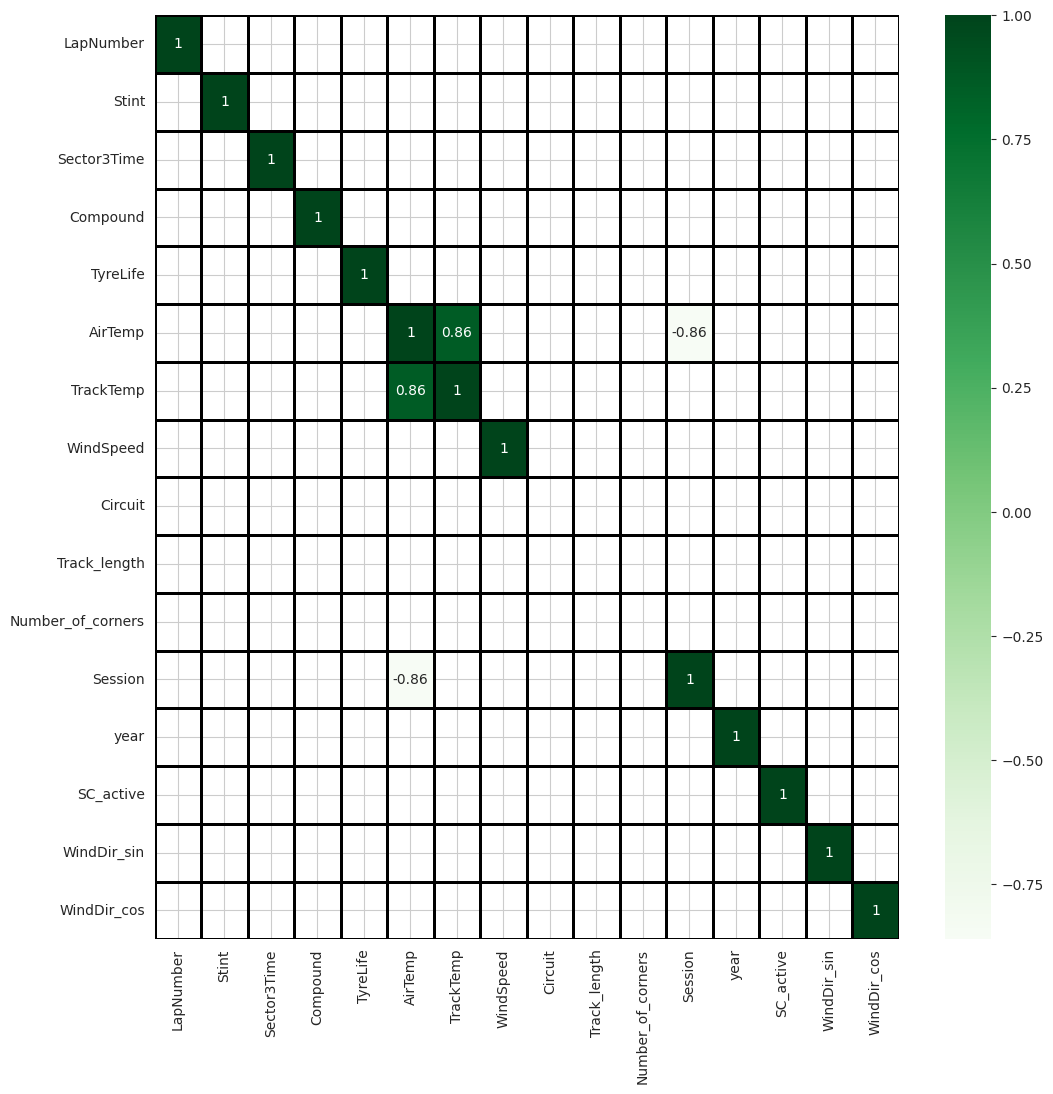

In [502]:
plt.figure(figsize=(12,12))
sns.heatmap(
    sect_3_corr_matrix,
    mask = sect_3_corr_matrix.abs() < 0.8,     ## our threshold for colienarity suspicion is 80% correlation between features
    annot=True,
    cmap="Greens",
    linewidths=0.75,
    linecolor="black"
    )
plt.show()

‘1’: Track clear (beginning of session or to indicate the end
    of another status)

‘2’: Yellow flag (sectors are unknown)

‘3’: ??? Never seen so far, does not exist?

‘4’: Safety Car

‘5’: Red Flag

‘6’: Virtual Safety Car deployed

‘7’: Virtual Safety Car ending (As indicated on the drivers steering wheel, on tv and so on; status ‘1’ will mark the actual end)

# Scaling

In [503]:
to_be_standardised = ['LapNumber','Stint','TyreLife','Session',"AirTemp","TrackTemp","WindSpeed","Track_length","Number_of_corners","year","WindDir_cos","WindDir_sin"]

standard_scaler_1 = StandardScaler()
standard_scaler_2 = StandardScaler()        # not necessary but makes it more diffiult to perform transformations with incorectly fit scalars later 
standard_scaler_3 = StandardScaler()

y_standard_scaler_1 = StandardScaler()
y_standard_scaler_2 = StandardScaler()
y_standard_scaler_3 = StandardScaler()


## S1

standard_scaler_1.fit(Ver_train_sector1[to_be_standardised])
y_standard_scaler_1.fit(Ver_train_sector1[["Sector1Time"]])


Ver_train_sector1[to_be_standardised] = standard_scaler_1.transform(Ver_train_sector1[to_be_standardised]) 
Ver_valid_sector1[to_be_standardised] = standard_scaler_1.transform(Ver_valid_sector1[to_be_standardised])
Ver_test_sector1[to_be_standardised] = standard_scaler_1.transform(Ver_test_sector1[to_be_standardised]) 

Ver_train_sector1["Sector1Time"] = y_standard_scaler_1.transform(Ver_train_sector1[["Sector1Time"]]) 
Ver_valid_sector1["Sector1Time"] = y_standard_scaler_1.transform(Ver_valid_sector1[["Sector1Time"]])
Ver_test_sector1["Sector1Time"] = y_standard_scaler_1.transform(Ver_test_sector1[["Sector1Time"]]) 

## S2

standard_scaler_2.fit(Ver_train_sector2[to_be_standardised])
y_standard_scaler_2.fit(Ver_train_sector2[["Sector2Time"]])

Ver_train_sector2[to_be_standardised] = standard_scaler_2.transform(Ver_train_sector2[to_be_standardised]) 
Ver_valid_sector2[to_be_standardised] = standard_scaler_2.transform(Ver_valid_sector2[to_be_standardised])
Ver_test_sector2[to_be_standardised] = standard_scaler_2.transform(Ver_test_sector2[to_be_standardised]) 

Ver_train_sector2["Sector2Time"] = y_standard_scaler_2.transform(Ver_train_sector2[["Sector2Time"]]) 
Ver_valid_sector2["Sector2Time"] = y_standard_scaler_2.transform(Ver_valid_sector2[["Sector2Time"]])
Ver_test_sector2["Sector2Time"] = y_standard_scaler_2.transform(Ver_test_sector2[["Sector2Time"]]) 


## S3

standard_scaler_3.fit(Ver_train_sector3[to_be_standardised])
y_standard_scaler_3.fit(Ver_train_sector3[["Sector3Time"]])

Ver_train_sector3[to_be_standardised] = standard_scaler_3.transform(Ver_train_sector3[to_be_standardised]) 
Ver_valid_sector3[to_be_standardised] = standard_scaler_3.transform(Ver_valid_sector3[to_be_standardised])
Ver_test_sector3[to_be_standardised] = standard_scaler_3.transform(Ver_test_sector3[to_be_standardised]) 

Ver_train_sector3["Sector3Time"] = y_standard_scaler_3.transform(Ver_train_sector3[["Sector3Time"]]) 
Ver_valid_sector3["Sector3Time"] = y_standard_scaler_3.transform(Ver_valid_sector3[["Sector3Time"]])
Ver_test_sector3["Sector3Time"] = y_standard_scaler_3.transform(Ver_test_sector3[["Sector3Time"]]) 

/tmp/ipykernel_213099/3478808900.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Ver_test_sector1[to_be_standardised] = standard_scaler_1.transform(Ver_test_sector1[to_be_standardised])
/tmp/ipykernel_213099/3478808900.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Ver_test_sector1["Sector1Time"] = y_standard_scaler_1.transform(Ver_test_sector1[["Sector1Time"]])
/tmp/ipykernel_213099/3478808900.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

# datasets

In [504]:
seq_length = 14
batchsize = 32

Ver_train_sector1_ds = make_ds(Ver_train_sector1, seq_length, batchsize, "Sector1Time", shuffle=True)               # data, seq length, batchsize,shuffle # needs to be numpy format
Ver_valid_sector1_ds = make_ds(Ver_valid_sector1, seq_length, batchsize, "Sector1Time", shuffle=False)
Ver_test_sector1_ds = make_ds(Ver_test_sector1, seq_length, batchsize, "Sector1Time", shuffle=False)

Ver_train_sector2_ds = make_ds(Ver_train_sector2, seq_length, batchsize, "Sector2Time", shuffle=True)               # data, seq length, batchsize,shuffle # needs to be numpy format
Ver_valid_sector2_ds = make_ds(Ver_valid_sector2, seq_length, batchsize, "Sector2Time", shuffle=False)
Ver_test_sector2_ds = make_ds(Ver_test_sector2, seq_length, batchsize, "Sector2Time", shuffle=False)

Ver_train_sector3_ds = make_ds(Ver_train_sector3, seq_length, batchsize, "Sector3Time", shuffle=True)               # data, seq length, batchsize,shuffle # needs to be numpy format
Ver_valid_sector3_ds = make_ds(Ver_valid_sector3, seq_length, batchsize, "Sector3Time", shuffle=False)
Ver_test_sector3_ds = make_ds(Ver_test_sector3, seq_length, batchsize, "Sector3Time", shuffle=False)


# Sanity Checks

In [505]:
for batch_x, batch_y in Ver_train_sector1_ds.take(1):          # takes firs t batch of datset
    print("X shape S1:", batch_x.shape)                        # (viable windows, seq_length, features)
    print("y shape S1:", batch_y.shape)                        # (viable windows) for single target

for batch_x, batch_y in Ver_valid_sector1_ds.take(1):
    print("X shape S2:", batch_x.shape)                        # (viable windows, seq_length, features)
    print("y shape S2:", batch_y.shape)                        # (viable windows,) for single target

for batch_x, batch_y in Ver_test_sector1_ds.take(1):
    print("X shape S3:", batch_x.shape)                        # (viable windows, seq_length, features)
    print("y shape S3:", batch_y.shape)                        # (viable windows,) for single target

X shape S1: (32, 14, 15)
y shape S1: (32,)
X shape S2: (16, 14, 15)
y shape S2: (16,)
X shape S3: (32, 14, 15)
y shape S3: (32,)


In [506]:
# Get the first window and its target

for batch_x, batch_y in Ver_train_sector1_ds.take(1):
    first_window = batch_x[0].numpy()
    first_target = batch_y[0].numpy()
    print("First window last row (features):", first_window[-1])
    print("First target (Sector1Time):", first_target)


First window last row (features): [-1.05207996e+00 -1.67977417e+00  2.00000000e+00 -5.82871251e-01
  1.35425641e+00  5.10548020e-01 -4.70651433e-01  0.00000000e+00
 -8.88178420e-16  0.00000000e+00 -1.25896550e+00  1.74311834e+00
  0.00000000e+00  1.24067348e+00 -9.90467175e-01]
First target (Sector1Time): -0.06247845


In [507]:
print("train windows:", tf.data.experimental.cardinality(Ver_train_sector1_ds))
print("valid windows:", tf.data.experimental.cardinality(Ver_valid_sector1_ds))
print("test  windows:", tf.data.experimental.cardinality(Ver_test_sector1_ds))   


train windows: tf.Tensor(8, shape=(), dtype=int64)
valid windows: tf.Tensor(1, shape=(), dtype=int64)
test  windows: tf.Tensor(2, shape=(), dtype=int64)


# Modelling

## Architecture

## Defining the Transformer

In [508]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

class PositionEmbedding(layers.Layer):
    """
    Learnable positional embedding for fixed-length windows.
    Adds a position vector of shape (seq_len, embed_dim) to the inputs.
    """
    def __init__(self, seq_len: int, embed_dim: int, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.embed_dim = embed_dim
        self.pos_emb = layers.Embedding(input_dim=seq_len, output_dim=embed_dim)

    def call(self, x):
        # x: (batch, seq_len, embed_dim)
        seq_len = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        pos_encoding = self.pos_emb(positions)  # (seq_len, embed_dim)
        return x + pos_encoding

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"seq_len": self.seq_len, "embed_dim": self.embed_dim})
        return cfg


class TransformerBlock(layers.Layer):
    """
    Pre-norm Transformer encoder block (LayerNorm -> MHA -> Dropout -> Residual -> FFN -> Residual).
    """
    def __init__(self, embed_dim: int, num_heads: int, ff_dim: int, rate: float = 0.1, **kwargs):
        super().__init__(**kwargs)
        # Per-head dimension; embed_dim should be divisible by num_heads
        key_dim = max(1, embed_dim // num_heads)

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=key_dim,            # dimension per head
            output_shape=embed_dim      # project output back to embed_dim for residual add
        )
        self.drop1 = layers.Dropout(rate)

        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim)
        ])
        self.drop2 = layers.Dropout(rate)

    def call(self, inputs, training=None):
        # Pre-norm
        x = self.norm1(inputs)
        attn_output = self.attn(x, x, training=training)
        attn_output = self.drop1(attn_output, training=training)
        x = inputs + attn_output                      # residual 1

        y = self.norm2(x)
        y = self.ffn(y, training=training)
        y = self.drop2(y, training=training)
        return x + y                                  # residual 2

In [509]:
def build_transformer_regressor(seq_len: int,
                                n_features: int,
                                embed_dim: int = 64,
                                num_heads: int = 4,
                                ff_dim: int = 128,
                                num_blocks: int = 2,
                                dropout: float = 0.1):
    """
    Returns a Keras model that takes (seq_len, n_features) and outputs a single scalar.
    """
    inputs = Input(shape=(seq_len, n_features))               # (B, T, F)

    # Project raw features to model dimension first so residuals are well-formed
    x = layers.Dense(embed_dim, name="feature_projection")(inputs)  # (B, T, E)

    # Add positional information
    x = PositionEmbedding(seq_len, embed_dim, name="positional_embedding")(x)

    # Stack N Transformer encoder blocks
    for i in range(num_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, rate=dropout, name=f"encoder_block_{i+1}")(x)

    # Normalise once at the end
    x = layers.LayerNormalization(epsilon=1e-6, name="final_norm")(x)

    # Option 1: use the last token (matches RNN patterns)
    x = layers.Lambda(lambda t: t[:, -1, :], name="last_token")(x)

    # Option 2 (alternative): GlobalAveragePooling1D to aggregate all timesteps
    # x = layers.GlobalAveragePooling1D(name="gap")(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, name="regression_head")(x)

    model = Model(inputs, outputs, name="transformer_time_series_regressor")
    return model

## Build the Transformers

In [510]:
# Ver_sector_1_model = build_transformer_regressor(seq_length,len(Ver_train_sector1.columns)-1)
# Ver_sector_2_model = build_transformer_regressor(seq_length,len(Ver_train_sector1.columns)-1)
# Ver_sector_3_model = build_transformer_regressor(seq_length,len(Ver_train_sector1.columns)-1)

## Defining the TSMixer

In [511]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

class TSMixerBlock(layers.Layer):
    """
    TSMixer block that preserves (B, T, F) across residuals.
    - Temporal mix: MLP over time axis (after transpose to make T the last dim), returns to T.
    - Feature mix:  MLP over feature axis, returns to F.
    """
    def __init__(self,
                 time_mlp_units: int = 64,
                 feature_mlp_units: int = 64,
                 dropout: float = 0.1,
                 **kwargs):
        super().__init__(**kwargs)
        self.time_mlp_units = time_mlp_units
        self.feature_mlp_units = feature_mlp_units
        self.dropout = layers.Dropout(dropout)

        # Pre-norms
        self.norm_time = layers.LayerNormalization(epsilon=1e-6)
        self.norm_feat = layers.LayerNormalization(epsilon=1e-6)

        # Temporal mixer (applied on (B,F,T))
        self.time_dense_1 = layers.Dense(time_mlp_units, activation="gelu")
        self.time_dense_2 = None   # will be Dense(T) in build()

        # Feature mixer (applied on (B,T,F))
        self.feature_dense_1 = layers.Dense(feature_mlp_units, activation="gelu")
        self.feature_dense_2 = None  # will be Dense(F) in build()

    def build(self, input_shape):
        # input_shape = (B, T, F)
        _, T, F = input_shape

        # Return to original sizes for residual adds
        self.time_dense_2 = layers.Dense(T)   # back to time length T
        self.feature_dense_2 = layers.Dense(F)  # back to feature size F

        super().build(input_shape)

    def call(self, x, training=None):
        # ----- Temporal mixing: mix over time axis -----
        t = self.norm_time(x)                         # (B, T, F)
        t = tf.transpose(t, perm=[0, 2, 1])          # (B, F, T)  → Dense acts on last axis (T)
        t = self.time_dense_1(t)                     # (B, F, Ht)
        t = self.time_dense_2(t)                     # (B, F, T)
        t = tf.transpose(t, perm=[0, 2, 1])          # (B, T, F)
        t = self.dropout(t, training=training)
        x = x + t                                     # residual, shapes now match

        # ----- Feature mixing: mix over feature axis -----
        f = self.norm_feat(x)                        # (B, T, F)
        f = self.feature_dense_1(f)                  # (B, T, Hf)
        f = self.feature_dense_2(f)                  # (B, T, F)
        f = self.dropout(f, training=training)
        x = x + f                                     # residual

        return x


def build_tsmixer_regressor(seq_len: int,
                            n_features: int,
                            depth: int = 3,
                            time_mlp_units: int = 64,
                            feature_mlp_units: int = 64,
                            dropout: float = 0.1):
    """
    (seq_len, n_features) → scalar. Uses last timestep representation for regression head.
    """
    inputs = Input(shape=(seq_len, n_features))  # (B, T, F)
    x = inputs

    for i in range(depth):
        x = TSMixerBlock(
            time_mlp_units=time_mlp_units,
            feature_mlp_units=feature_mlp_units,
            dropout=dropout,
            name=f"tsmixer_block_{i+1}",
        )(x)

    x = layers.LayerNormalization(epsilon=1e-6, name="final_norm")(x)
    x = layers.Lambda(lambda t: t[:, -1, :], name="last_token")(x)  # (B, F)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, name="regression_head")(x)

    return Model(inputs, outputs, name="tsmixer_time_series_regressor")

## Build TSMixers

In [512]:

# Ver_sector_1_model = build_tsmixer_regressor(
#     seq_len=seq_length,
#     n_features=len(Ver_train_sector1.columns) - 1,   # drop the single target
#     depth=3,
#     time_mlp_units=64,
#     feature_mlp_units=64,
#     dropout=0.1
# )

# Ver_sector_2_model = build_tsmixer_regressor(
#     seq_len=seq_length,
#     n_features=len(Ver_train_sector2.columns) - 1,   # <-- was sector1 by mistake
#     depth=3,
#     time_mlp_units=64,
#     feature_mlp_units=64,
#     dropout=0.1
# )

# Ver_sector_3_model = build_tsmixer_regressor(
#     seq_len=seq_length,
#     n_features=len(Ver_train_sector3.columns) - 1,   # <-- was sector1 by mistake
#     depth=3,
#     time_mlp_units=64,
#     feature_mlp_units=64,
#     dropout=0.1
# )

### Sector 1 model

In [513]:
Ver_sector_1_model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(seq_length, len(Ver_train_sector1.columns)-1)),
    tf.keras.layers.Conv1D(
        filters=16,
        kernel_size=5,
        padding="causal",                       ### looks back not forward, no leakage
        use_bias=False,
        activation="relu"
    ),
    tf.keras.layers.Conv1D(
        filters=32,
        kernel_size=3,
        padding="causal",                       ### looks back not forward, no leakage
        use_bias=False,
        activation="relu"
    ),
    tf.keras.layers.SpatialDropout1D(0.05),                     ##only after first batch on cnns as every layer would lead to more lag
    tf.keras.layers.LayerNormalization(),

    tf.keras.layers.LSTM(128, return_sequences=True),                                   ## return sequences is needed otherwise only last hidden state is returned                          
    tf.keras.layers.LSTM(64),
    tf.keras.layers.LayerNormalization(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(64, activation="relu"),
    
    tf.keras.layers.Dense(1)
])   

### Sector 2 model

In [514]:
Ver_sector_2_model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(seq_length, len(Ver_train_sector1.columns)-1)),
    tf.keras.layers.Conv1D(
        filters=16,
        kernel_size=5,
        padding="causal",                       ### looks back not forward, no leakage
        use_bias=False,
        activation="relu"
    ),
    tf.keras.layers.Conv1D(
        filters=32,
        kernel_size=3,
        padding="causal",                       ### looks back not forward, no leakage
        use_bias=False,
        activation="relu"
    ),
    tf.keras.layers.SpatialDropout1D(0.05),                     ##only after first batch on cnns as every layer would lead to more lag
    tf.keras.layers.LayerNormalization(),

    tf.keras.layers.LSTM(128, return_sequences=True),                                   ## return sequences is needed otherwise only last hidden state is returned                          
    tf.keras.layers.LSTM(64),
    tf.keras.layers.LayerNormalization(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(64, activation="relu"),
    
    tf.keras.layers.Dense(1)
])                                                

### Sector 3 model

In [515]:
Ver_sector_3_model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(seq_length, len(Ver_train_sector1.columns)-1)),
    tf.keras.layers.Conv1D(
        filters=16,
        kernel_size=5,
        padding="causal",                       ### looks back not forward, no leakage
        use_bias=False,
        activation="relu"
    ),
    tf.keras.layers.Conv1D(
        filters=32,
        kernel_size=3,
        padding="causal",                       ### looks back not forward, no leakage
        use_bias=False,
        activation="relu"
    ),
    tf.keras.layers.SpatialDropout1D(0.05),                     ##only after first batch on cnns as every layer would lead to more lag
    tf.keras.layers.LayerNormalization(),

    tf.keras.layers.LSTM(128, return_sequences=True),                                   ## return sequences is needed otherwise only last hidden state is returned                          
    tf.keras.layers.LSTM(64),
    tf.keras.layers.LayerNormalization(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(64, activation="relu"),
    
    tf.keras.layers.Dense(1)
])   

**Effective receptive field of the cnn layers = the sum of the kernel sizes - the number of layers. This really should be less than sequence length to avoid delayed reactions.**

## Running Models

### Sector 1

In [516]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_mae",
    patience=50,
    restore_best_weights=True)

reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_mae",
    factor=0.5,          # reduce LR by half
    patience=10,         # wait this many epochs without improvement
    min_lr=2e-6,         # floor
    verbose=1
)

opt = tf.keras.optimizers.AdamW(
    learning_rate=0.001,
    beta_1 =0.9,
    beta_2 = 0.999,
    weight_decay=0.0001,
    clipnorm=1.0  
    )

Ver_sector_1_model.compile(
    loss=tf.keras.losses.MeanAbsoluteError(),
    optimizer=opt,
    metrics=["mae"])

history = Ver_sector_1_model.fit(
    Ver_train_sector1_ds,
    validation_data = Ver_valid_sector1_ds,
    callbacks = [early_stopping_cb,reduce_lr_cb],
    epochs=1000)

Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.6557 - mae: 0.6557 - val_loss: 0.1930 - val_mae: 0.1930 - learning_rate: 0.0010
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4749 - mae: 0.4749 - val_loss: 0.1475 - val_mae: 0.1475 - learning_rate: 0.0010
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4577 - mae: 0.4577 - val_loss: 0.1083 - val_mae: 0.1083 - learning_rate: 0.0010
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4067 - mae: 0.4067 - val_loss: 0.0633 - val_mae: 0.0633 - learning_rate: 0.0010
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4202 - mae: 0.4202 - val_loss: 0.1024 - val_mae: 0.1024 - learning_rate: 0.0010
Epoch 6/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3954 - mae: 0.3954 - val_loss: 0.1383 - val_mae: 0.1383 - learning_rate: 0.0010
Epoch 7/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3819 - mae: 0.3819 - val_loss: 0.0707 - val_mae: 0.0707 - learning_rate: 0.0010
Epoch 8/1000


### Sector 2

In [517]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_mae",
    patience=50,
    restore_best_weights=True)

reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_mae",
    factor=0.5,          # reduce LR by half
    patience=10,         # wait this many epochs without improvement
    min_lr=2e-6,         # floor
    verbose=1
)

opt = tf.keras.optimizers.AdamW(
    learning_rate=0.001,
    beta_1 =0.9,
    beta_2 = 0.999,
    weight_decay=0.0001,
    clipnorm=1.0  
    )

Ver_sector_2_model.compile(
    loss=tf.keras.losses.MeanAbsoluteError(),
    optimizer=opt,
    metrics=["mae"])

history = Ver_sector_2_model.fit(
    Ver_train_sector2_ds,
    validation_data = Ver_valid_sector2_ds,
    callbacks = [early_stopping_cb,reduce_lr_cb],
    epochs=1000)

Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.6279 - mae: 0.6279 - val_loss: 0.1820 - val_mae: 0.1820 - learning_rate: 0.0010
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4362 - mae: 0.4362 - val_loss: 0.0512 - val_mae: 0.0512 - learning_rate: 0.0010
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3841 - mae: 0.3841 - val_loss: 0.1804 - val_mae: 0.1804 - learning_rate: 0.0010
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3963 - mae: 0.3963 - val_loss: 0.0691 - val_mae: 0.0691 - learning_rate: 0.0010
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3618 - mae: 0.3618 - val_loss: 0.0475 - val_mae: 0.0475 - learning_rate: 0.0010
Epoch 6/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3563 - mae: 0.3563 - val_loss: 0.0732 - val_mae: 0.0732 - learning_rate: 0.0010
Epoch 7/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3156 - mae: 0.3156 - val_loss: 0.0366 - val_mae: 0.0366 - learning_rate: 0.0010
Epoch 8/1000


### Sector 3

In [518]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_mae",
    patience=50,
    restore_best_weights=True)

reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_mae",
    factor=0.5,          # reduce LR by half
    patience=10,         # wait this many epochs without improvement
    min_lr=2e-6,         # floor
    verbose=1
)


opt = tf.keras.optimizers.AdamW(
    learning_rate=0.001,
    beta_1 =0.9,
    beta_2 = 0.999,
    weight_decay=0.0001,
    clipnorm=1.0  
    )

Ver_sector_3_model.compile(
    loss=tf.keras.losses.MeanAbsoluteError(),
    optimizer=opt,
    metrics=["mae"])

history = Ver_sector_3_model.fit(
    Ver_train_sector3_ds,
    validation_data = Ver_valid_sector3_ds,
    callbacks = [early_stopping_cb,reduce_lr_cb],
    epochs=1000)

Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.6310 - mae: 0.6310 - val_loss: 0.1279 - val_mae: 0.1279 - learning_rate: 0.0010
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5345 - mae: 0.5345 - val_loss: 0.4268 - val_mae: 0.4268 - learning_rate: 0.0010
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4478 - mae: 0.4478 - val_loss: 0.0993 - val_mae: 0.0993 - learning_rate: 0.0010
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4353 - mae: 0.4353 - val_loss: 0.1490 - val_mae: 0.1490 - learning_rate: 0.0010
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4236 - mae: 0.4236 - val_loss: 0.1080 - val_mae: 0.1080 - learning_rate: 0.0010
Epoch 6/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3551 - mae: 0.3551 - val_loss: 0.1513 - val_mae: 0.1513 - learning_rate: 0.0010
Epoch 7/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3781 - mae: 0.3781 - val_loss: 0.0708 - val_mae: 0.0708 - learning_rate: 0.0010
Epoch 8/1000


## Results

In [519]:
test_loss_1, test_mae_1 = Ver_sector_1_model.evaluate(Ver_test_sector1_ds)
print("Sector 1 Test MAE:", test_mae_1)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1641 - mae: 0.1641
Sector 1 Test MAE: 0.1641121357679367


In [520]:
test_loss_2, test_mae_2 = Ver_sector_2_model.evaluate(Ver_test_sector2_ds)
print("Sector 2 Test MAE:", test_mae_2)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2729 - mae: 0.2729
Sector 2 Test MAE: 0.2729203701019287


In [521]:
test_loss_3, test_mae_3 = Ver_sector_3_model.evaluate(Ver_test_sector3_ds)
print("Sector 3 Test MAE:", test_mae_3)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2846 - mae: 0.2846
Sector 3 Test MAE: 0.28459063172340393


In [522]:
preds_1 = Ver_sector_1_model.predict(Ver_test_sector1_ds)
preds_1 = y_standard_scaler_1.inverse_transform(preds_1)
preds_1

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step


array([[31.320066],
       [31.31332 ],
       [31.323864],
       [31.33023 ],
       [31.350924],
       [31.343033],
       [31.35125 ],
       [31.371841],
       [31.367016],
       [31.403833],
       [31.426554],
       [31.482204],
       [31.446926],
       [31.466366],
       [31.453484],
       [31.44912 ],
       [31.429968],
       [31.442537],
       [31.423143],
       [31.458458],
       [31.466854],
       [31.351263],
       [31.3636  ],
       [31.367334],
       [31.36561 ],
       [31.367922],
       [31.37653 ],
       [31.553886],
       [31.433876],
       [31.395021],
       [31.399931],
       [31.395643],
       [31.38736 ],
       [31.340574],
       [31.352804],
       [31.330116],
       [31.270163],
       [31.235182],
       [31.212566],
       [31.210264],
       [31.174221],
       [31.144619]], dtype=float32)

In [523]:
preds_2 = Ver_sector_2_model.predict(Ver_test_sector2_ds)
preds_2 = y_standard_scaler_2.inverse_transform(preds_2)
preds_2

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


array([[43.542362],
       [43.427776],
       [43.284023],
       [43.154976],
       [43.118736],
       [43.112793],
       [43.186005],
       [43.069294],
       [42.91972 ],
       [42.796265],
       [42.789303],
       [42.803314],
       [42.84061 ],
       [43.17263 ],
       [43.340668],
       [43.343414],
       [43.386772],
       [43.48029 ],
       [43.493046],
       [43.586334],
       [43.43827 ],
       [43.663864],
       [43.62271 ],
       [43.69054 ],
       [44.051918],
       [45.65781 ],
       [43.585518],
       [42.973602],
       [42.799347],
       [42.787384],
       [42.86882 ],
       [42.77607 ],
       [42.870453],
       [42.836006],
       [42.93448 ],
       [42.884525],
       [42.75264 ],
       [42.829636],
       [42.813023],
       [42.815258],
       [42.871284],
       [42.88688 ]], dtype=float32)

In [524]:
preds_3 = Ver_sector_3_model.predict(Ver_test_sector3_ds)
preds_3 = y_standard_scaler_3.inverse_transform(preds_3)
preds_3


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


array([[24.57866 ],
       [24.602097],
       [24.587753],
       [24.599688],
       [24.567122],
       [24.548113],
       [24.556345],
       [24.577156],
       [24.653225],
       [24.652521],
       [24.642286],
       [24.584446],
       [24.557014],
       [24.47567 ],
       [24.430988],
       [24.378988],
       [24.369474],
       [24.378407],
       [24.334896],
       [24.320597],
       [24.15193 ],
       [24.333109],
       [24.175758],
       [23.95566 ],
       [23.791946],
       [23.718193],
       [23.70731 ],
       [23.66687 ],
       [23.728043],
       [23.963646],
       [24.078327],
       [24.135593],
       [24.19558 ],
       [24.20944 ],
       [24.247599],
       [24.180264],
       [24.197634],
       [24.251835],
       [24.18237 ],
       [24.153765],
       [24.140636],
       [23.99318 ]], dtype=float32)

# Data surgery - Stitching predictions and reality back together

testing split starts at split_index_2 and will start predicting rom row index (index_2 + sequence length)

In [525]:
global_split_index_2

300

In [526]:
len(preds_1)

42

In [527]:
Test_pred_real = Bahrain_Ver_df[(Bahrain_Ver_df["Session"] == 4) & (Bahrain_Ver_df["year"] == 2025)].iloc[seq_length:seq_length+len(preds_1)][["LapNumber","Sector1Time","Sector2Time","Sector3Time","Compound"]]       # sequence length starts at 0
Test_pred_real[["Sector1_pred","Sector2_pred","Sector3_pred"]] = np.hstack([preds_1,preds_2,preds_3])
Test_pred_real["LapTime"] = Test_pred_real["Sector1Time"] + Test_pred_real["Sector2Time"] + Test_pred_real["Sector3Time"]
Test_pred_real["Predicted_LapTime"] = Test_pred_real["Sector1_pred"] + Test_pred_real["Sector2_pred"] + Test_pred_real["Sector3_pred"]

Test_pred_real["Lap_pred_delta"] = Test_pred_real["LapTime"] - Test_pred_real["Predicted_LapTime"]
Test_pred_real["Sector1_pred_delta"] = abs(Test_pred_real["Sector1Time"] - Test_pred_real["Sector1_pred"])
Test_pred_real["Sector2_pred_delta"] = abs(Test_pred_real["Sector2Time"] - Test_pred_real["Sector2_pred"])
Test_pred_real["Sector3_pred_delta"] = abs(Test_pred_real["Sector3Time"] - Test_pred_real["Sector3_pred"])

Test_pred_real = Test_pred_real[["LapNumber",
                                 "LapTime",
                                 "Predicted_LapTime",
                                 "Lap_pred_delta",
                                 "Sector1Time",
                                 "Sector1_pred",
                                 "Sector1_pred_delta",
                                 "Sector2Time",
                                 "Sector2_pred",
                                 "Sector2_pred_delta",
                                 "Sector3Time",
                                 "Sector3_pred",
                                 "Sector3_pred_delta",
                                 "Compound"]]

In [528]:
import numpy as np

def best_shift(y_true, y_pred, kmax=3):
    ks, maes = [], []
    for k in range(-kmax, kmax+1):
        if k < 0:
            yt = y_true[-k:]
            yp = y_pred[:len(yt)]
        elif k > 0:
            yt = y_true[:-k]
            yp = y_pred[k:]
        else:
            yt = y_true
            yp = y_pred
        ks.append(k)
        maes.append(np.mean(np.abs(yt - yp)))
    k_best = ks[int(np.argmin(maes))]
    return k_best, list(zip(ks, maes))

# Example:
# k_best, scores = best_shift(aligned_df["LapTime"].to_numpy(), aligned_df["Predicted_LapTime"].to_numpy(), 3)
# print("Best shift:", k_best, "MAEs:", scores)

In [529]:
Test_pred_real

,LapNumber,LapTime,Predicted_LapTime,Lap_pred_delta,Sector1Time,Sector1_pred,Sector1_pred_delta,Sector2Time,Sector2_pred,Sector2_pred_delta,Sector3Time,Sector3_pred,Sector3_pred_delta,Compound
189,16.0,99.303,99.441086,-0.138086,31.259,31.320066,0.061066,43.322,43.542362,0.220362,24.722,24.578659,0.143341,C1
192,17.0,98.408,99.343193,-0.935193,31.268,31.313320,0.045320,42.801,43.427776,0.626776,24.339,24.602097,0.263097,C1
197,18.0,98.553,99.195641,-0.642641,31.151,31.323864,0.172864,42.950,43.284023,0.334023,24.452,24.587753,0.135753,C1
200,19.0,98.515,99.084892,-0.569892,31.078,31.330231,0.252231,42.988,43.154976,0.166976,24.449,24.599688,0.150688,C1
207,20.0,100.427,99.036781,1.390219,31.993,31.350924,0.642076,43.988,43.118736,0.869264,24.446,24.567122,0.121122,C1
209,21.0,98.948,99.003937,-0.055937,31.207,31.343033,0.136033,43.163,43.112793,0.050207,24.578,24.548113,0.029887,C1
213,22.0,100.076,99.093597,0.982403,31.627,31.351250,0.275750,43.856,43.186005,0.669995,24.593,24.556345,0.036655,C1
219,23.0,98.433,99.018288,-0.585288,31.033,31.371841,0.338841,42.911,43.069294,0.158294,24.489,24.577156,0.088156,C1
221,24.0,98.871,98.939957,-0.068957,31.598,31.367016,0.230984,42.867,42.919720,0.052720,24.406,24.653225,0.247225,C1
227,25.0,99.492,98.852615,0.639385,31.608,31.403833,0.204167,43.181,42.796265,0.384735,24.703,24.652521,0.050479,C1



‘1’: Track clear (beginning of session or to indicate the end of another status)

‘2’: Yellow flag (sectors are unknown)

‘3’: ??? Never seen so far, does not exist?

‘4’: Safety Car

‘5’: Red Flag

‘6’: Virtual Safety Car deployed

‘7’: Virtual Safety Car ending (As indicated on the drivers steering wheel, on tv and so on; status ‘1’ will mark the actual end)

# Plots

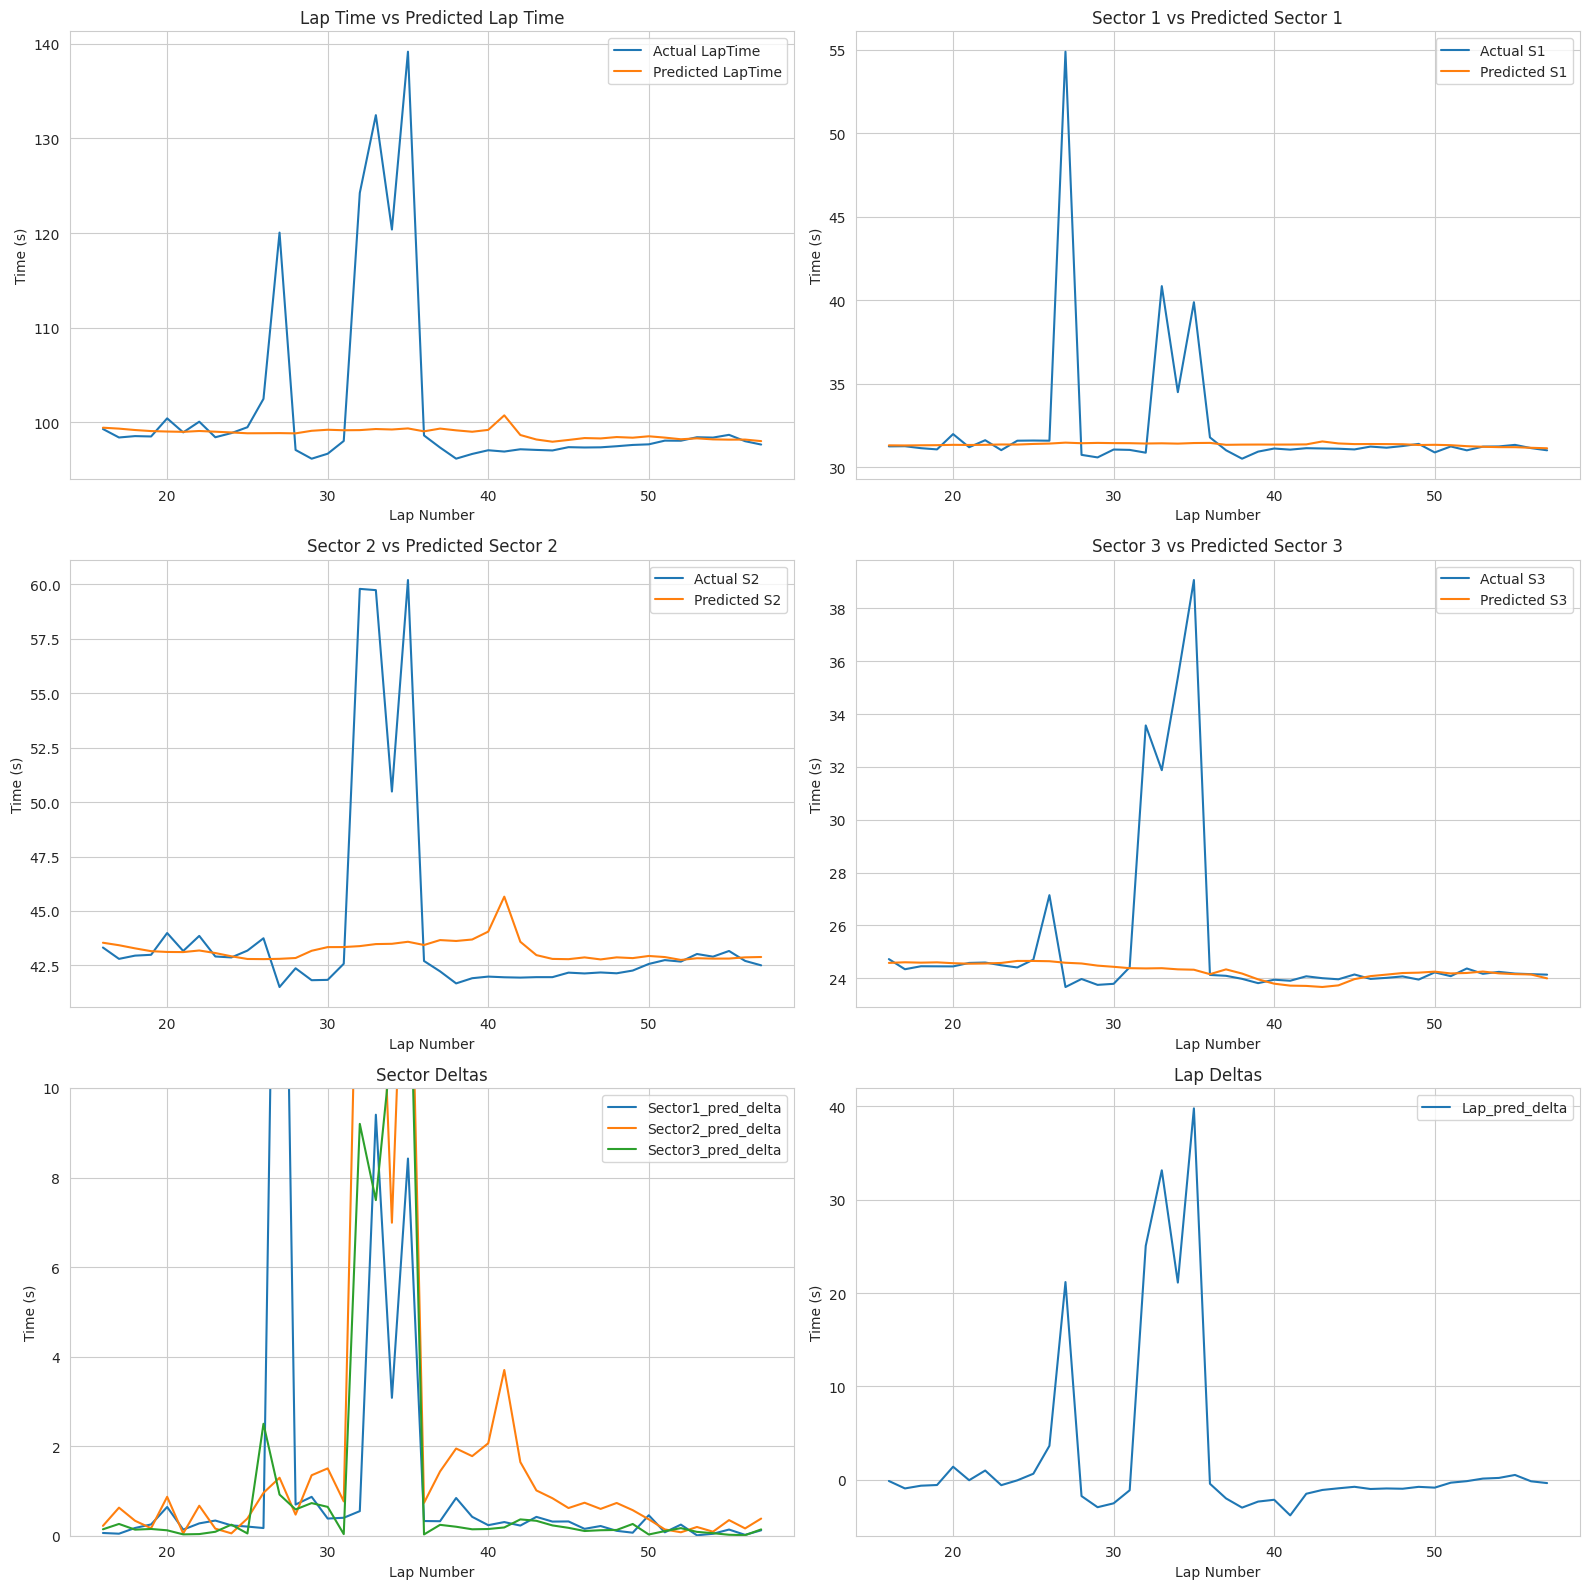

In [530]:


plt.figure(figsize=(16, 16))

# ----------------------------
# 1. LapTime vs Predicted LapTime
# ----------------------------
plt.subplot(3, 2, 1)
sns.lineplot(data=Test_pred_real, x="LapNumber", y="LapTime", label="Actual LapTime")
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Predicted_LapTime", label="Predicted LapTime")
plt.title("Lap Time vs Predicted Lap Time")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
# plt.ylim(90, 110)

# ----------------------------
# 2. Sector 1
# ----------------------------
plt.subplot(3, 2, 2)
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Sector1Time", label="Actual S1")
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Sector1_pred", label="Predicted S1")
plt.title("Sector 1 vs Predicted Sector 1")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
# plt.ylim(25, 40)

# ----------------------------
# 3. Sector 2
# ----------------------------
plt.subplot(3, 2, 3)
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Sector2Time", label="Actual S2")
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Sector2_pred", label="Predicted S2")
plt.title("Sector 2 vs Predicted Sector 2")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
# plt.ylim(25, 40)

# ----------------------------
# 4. Sector 3
# ----------------------------
plt.subplot(3, 2, 4)
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Sector3Time", label="Actual S3")
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Sector3_pred", label="Predicted S3")
plt.title("Sector 3 vs Predicted Sector 3")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
# plt.ylim(25, 40)
# ----------------------------
# 5. Sector prediction deltas
# ----------------------------

plt.subplot(3, 2, 5)
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Sector1_pred_delta", label="Sector1_pred_delta")
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Sector2_pred_delta", label="Sector2_pred_delta")
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Sector3_pred_delta", label="Sector3_pred_delta")
plt.title("Sector Deltas")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
plt.ylim(0, 10)

# ----------------------------
# 6. Lap prediction deltas
# ----------------------------

plt.subplot(3, 2, 6)
sns.lineplot(data=Test_pred_real, x="LapNumber", y="Lap_pred_delta", label="Lap_pred_delta")
plt.title("Lap Deltas")
plt.xlabel("Lap Number")
plt.ylabel("Time (s)")
# plt.ylim(0, 20)

plt.tight_layout()
plt.show()